In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import zipfile

In [2]:
output_dir = Path("/mnt/data/taller_cv_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:

h, w = 512, 512
img = np.full((h, w, 3), 220, dtype=np.uint8)


cv2.rectangle(img, (40, 60), (200, 200), (0, 255, 0), -1)
cv2.circle(img, (360, 140), 70, (0, 0, 255), -1)
pts = np.array([[260,320],[420,360],[320,440]], np.int32)
cv2.fillPoly(img, [pts], (255,0,0))


overlay = img.copy()
cv2.rectangle(overlay, (50,300),(230,480),(0,120,200), -1)
alpha = 0.5
cv2.addWeighted(overlay, alpha, img, 1-alpha, 0, img)


cv2.putText(img, "TEST 3D/IMG", (60, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50,50,50), 2, cv2.LINE_AA)


orig_path = output_dir/"01_original.png"
cv2.imwrite(str(orig_path), img)


True

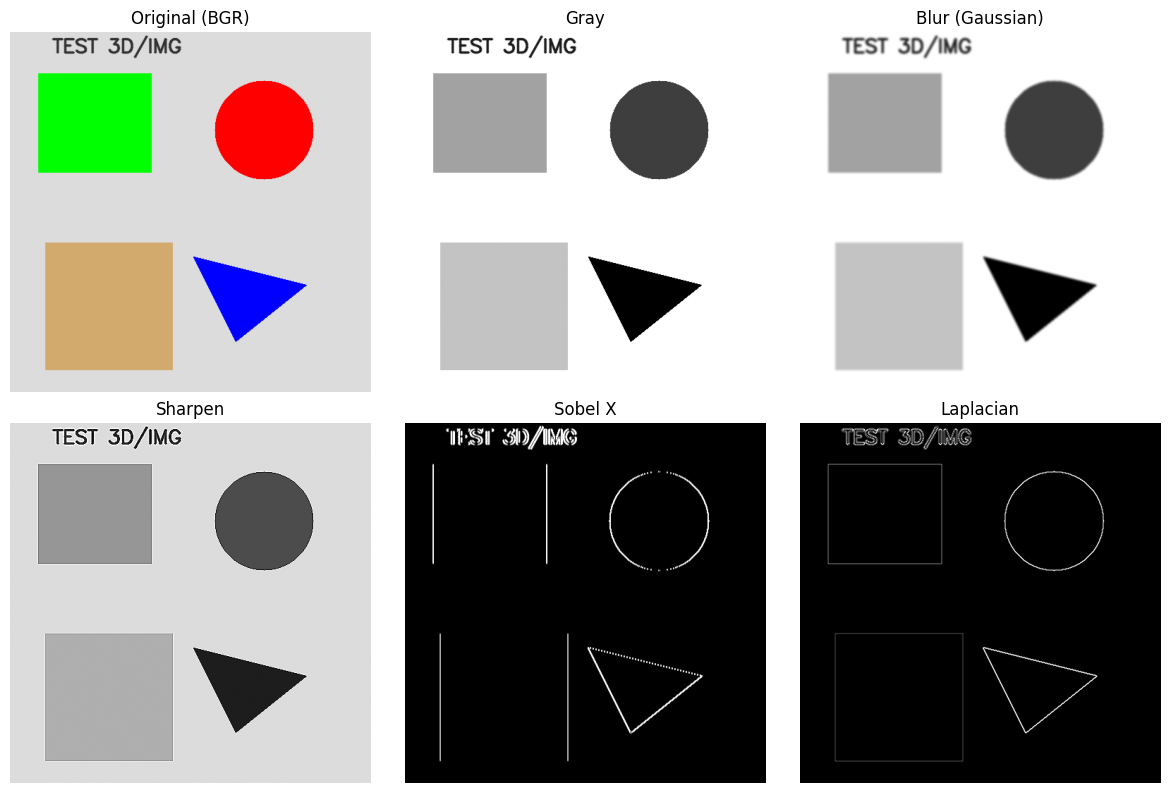

In [4]:

# -------------------------
# Ejercicio 2 - Ojos Digitales
# -------------------------
def exercise_2(image):
    results = {}

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    results['gray'] = gray

    blur = cv2.GaussianBlur(gray, (7,7), 1.5)
    results['blur'] = blur

    kernel_sharp = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharpen = cv2.filter2D(gray, -1, kernel_sharp)
    results['sharpen'] = sharpen

    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    sobelx_u = cv2.convertScaleAbs(sobelx)
    sobely_u = cv2.convertScaleAbs(sobely)
    results['sobelx'] = sobelx_u
    results['sobely'] = sobely_u

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    lap_u = cv2.convertScaleAbs(lap)
    results['laplacian'] = lap_u
    return results

res2 = exercise_2(img)


fig, axes = plt.subplots(2,3, figsize=(12,8))
axes = axes.ravel()
titles = ['Original (BGR)', 'Gray', 'Blur (Gaussian)', 'Sharpen', 'Sobel X', 'Laplacian']
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), res2['gray'], res2['blur'], res2['sharpen'], res2['sobelx'], res2['laplacian']]

for ax, im, t in zip(axes, images, titles):
    if im.ndim==2:
        ax.imshow(im, cmap='gray')
    else:
        ax.imshow(im)
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
ex2_path = output_dir/"exercise_2_results.png"
plt.savefig(str(ex2_path), dpi=150)
plt.show()